In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('placement.csv')
data.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [7]:
data.set_index('Unnamed: 0',inplace=True)
data.index.name=None

In [8]:
data.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


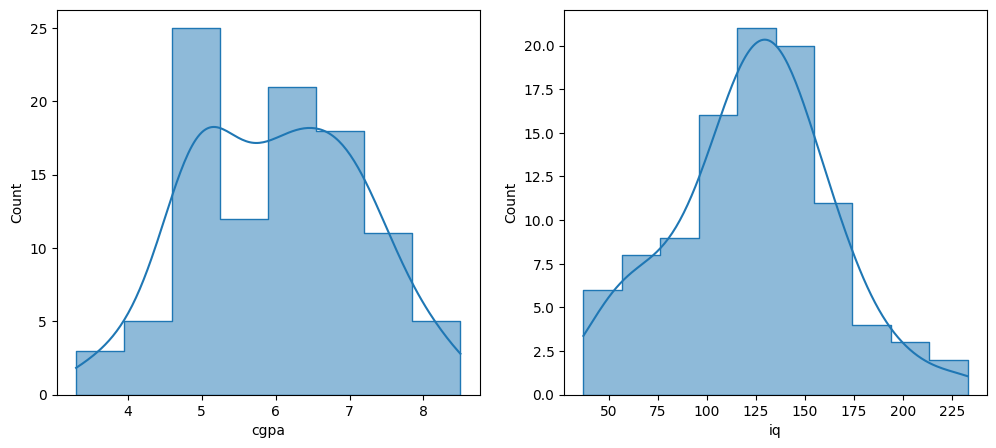

In [13]:
fig=plt.figure(figsize=(12,5))
ax1=fig.add_subplot(121)
sns.histplot(x=data['cgpa'],element='step',kde=True,ax=ax1)

ax2=fig.add_subplot(122)
sns.histplot(x=data['iq'],element='step',kde=True,ax=ax2)
plt.show()

In [14]:
print('Info About CGPA:')
print('Mean: ',data['cgpa'].mean())
print('STD: ',data['cgpa'].std())
print('Min: ',data['cgpa'].min())
print('Max: ',data['cgpa'].max())

Info About CGPA:
Mean:  5.9910000000000005
STD:  1.1436336737775692
Min:  3.3
Max:  8.5


In [15]:
print('Info About IQ:')
print('Mean: ',data['iq'].mean())
print('STD: ',data['iq'].std())
print('Min: ',data['iq'].min())
print('Max: ',data['iq'].max())

Info About IQ:
Mean:  123.58
STD:  39.944198451076595
Min:  37.0
Max:  233.0


In [18]:
# finding boundry values in cgpa
print("Highest Allowed ",data['cgpa'].quantile(0.75)+(1.5*(data['cgpa'].quantile(0.75)-data['cgpa'].quantile(0.25))))
print("Lowest Allowed ",data['cgpa'].quantile(0.25)-(1.5*(data['cgpa'].quantile(0.75)-data['cgpa'].quantile(0.25))))

Highest Allowed  9.637500000000003
Lowest Allowed  2.3374999999999977


In [19]:
# finding boundry values in iq
print("Highest Allowed ",data['iq'].quantile(0.75)+(1.5*(data['iq'].quantile(0.75)-data['iq'].quantile(0.25))))
print("Lowest Allowed ",data['iq'].quantile(0.25)-(1.5*(data['iq'].quantile(0.75)-data['iq'].quantile(0.25))))

Highest Allowed  220.25
Lowest Allowed  30.25


In [23]:
data[(data['cgpa']>9.637) | (data['cgpa']<2.337)]

,cgpa,iq,placement


In [24]:
data[(data['iq']>220.25) | (data['iq']<30.25)]

,cgpa,iq,placement
16,5.2,224.0,0
50,3.5,233.0,0


In [28]:
# trimming
new_df=data[(data['iq']<220.25) & (data['iq']>30.25)]

In [29]:
new_df.shape

(98, 3)

In [27]:
data.shape

(100, 3)

In [30]:
data['z_score_iq']=(data['iq']-data['iq'].mean())/data['iq'].std()

In [36]:
data[data['z_score_iq']<-3]

,cgpa,iq,placement,z_score_iq


In [41]:
(224.0 - 123.58)/data['iq'].std()

np.float64(2.5140071373066553)

In [52]:
upper=data['iq'].quantile(0.75)+(1.5*(data['iq'].quantile(0.75)-data['iq'].quantile(0.25)))
lower=data['iq'].quantile(0.25)-(1.5*(data['iq'].quantile(0.75)-data['iq'].quantile(0.25)))

In [46]:
upper,lower

(np.float64(220.25), np.float64(30.25))

In [44]:
# upper=data['iq'].mean()+3*data['iq'].std()
# lower=data['iq'].mean()-3*data['iq'].std()
# upper,lower

(np.float64(243.4125953532298), np.float64(3.747404646770221))

In [ ]:
# here z-score boundry and iqr boundry are diffrent because std dominate from outliers
# data has skewed

In [49]:
data['iq']=np.where(
    data['iq']>upper,
    upper,
    np.where(
        data['iq']<lower,lower,data['cgpa'])
)

In [57]:
data['iq'].describe()

count    100.000000
mean      10.309000
std       30.163189
min        3.300000
25%        5.100000
50%        6.100000
75%        6.925000
max      220.250000
Name: iq, dtype: float64